In [40]:
import numpy as np
import math as math
from scipy import optimize
import matplotlib.pylab as plt
from matplotlib.legend_handler import HandlerLine2D
import pandas as pd

%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
pass

In [ ]:
# Tunnel inputs

segment_length = 25         # m
n_cables = 2

q_up = 250                  # kN/m, upward force of tunnel segment
q_traffic_down = 54         # kN/m, downward traffic load

F_up_empty_kN = q_up * segment_length
F_traffic_down_kN = q_traffic_down * segment_length

F_required_empty_kN = F_up_empty_kN
F_required_full_kN = F_up_empty_kN - F_traffic_down_kN

print("Upward force empty tunnel segment:", F_up_empty_kN, "kN")
print("Downward traffic load:", F_traffic_down_kN, "kN")
print("Required downward cable force, empty tunnel:", F_required_empty_kN, "kN total")
print("Required downward cable force, full traffic:", F_required_full_kN, "kN total")
print("Required per cable, empty tunnel:", F_required_empty_kN / n_cables, "kN")
print("Required per cable, full traffic:", F_required_full_kN / n_cables, "kN")

F_required_empty = F_required_empty_kN * 1000
F_required_full = F_required_full_kN * 1000

x = np.arange(0, 10000 + 25, 25)

x_known = np.array([0, 5000, 10000])
depth_known = np.array([275, 217.5, 160])

depth = np.interp(x, x_known, depth_known)

df_depths = pd.DataFrame({
    "x_m": x,
    "depth_m": depth
})


print(df_depths)

Upward force empty tunnel segment: 6250 kN
Downward traffic load: 1350 kN
Required downward cable force, empty tunnel: 6250 kN total
Required downward cable force, full traffic: 4900 kN total
Required per cable, empty tunnel: 3125.0 kN
Required per cable, full traffic: 2450.0 kN
       x_m   depth_m
0        0  275.0000
1       25  274.7125
2       50  274.4250
3       75  274.1375
4      100  273.8500
..     ...       ...
396   9900  161.1500
397   9925  160.8625
398   9950  160.5750
399   9975  160.2875
400  10000  160.0000

[401 rows x 2 columns]


In [ ]:
g = 9.81 #m/s2
chain_diameter = 0.162 #m
W_pm = 575 #kg/m
EA = 1.01*(10**8)*chain_diameter**2 * 1000 #N

V_target_kN = F_required_empty_kN / n_cables - (F_required_empty_kN / n_cables - F_required_full_kN / n_cables) * 1/3        
V_target = V_target_kN * 1000   
min_bed_length = 110             
dL = 0.1                   
dx_anchor = 5             

print("Target vertical force:", V_target_kN, "kN")

Target vertical force: 2900.0 kN


In [43]:
def catenary_end_xz(W_pm, L_tot, EA, V_AN, H_AN, L_susp):
    
    W = W_pm*L_susp*g
        
    s = L_susp    
    z_t1 = 1 + (V_AN/H_AN)**2
    z_t2 = 1 + ((V_AN - W*s/L_susp)/H_AN)**2
    z = W*s/EA * (s/2/L_susp - V_AN/W) - H_AN*L_susp/W*(np.sqrt(z_t1) - np.sqrt(z_t2))            
    x_susp = H_AN*s/EA + H_AN*L_susp/W*(np.arcsinh(V_AN/H_AN) - np.arcsinh((V_AN - W*s/L_susp)/H_AN))
    x_bed = L_tot - L_susp
    x = x_bed + x_susp
        
    return x, z

def plot_catenary_xz(W_pm, L_tot, EA, V_AN, H_AN, L_susp, ds):
        
    W = W_pm * L_susp * g
    
    # c_s = [0]
    # c_x = [L_tot - L_susp]
    # c_z = [0]
    # c_H = [H_AN]
    # c_V = [V_AN]
    
    c_s = [0, 0]    
    c_x = [0, L_tot - L_susp]
    c_z = [0, 0]
    c_H = [H_AN, H_AN]
    c_V = [V_AN, V_AN]
    
    Ns = math.floor(L_susp/ds)
    ds = L_susp/Ns
    for i in range(1,Ns+1):
        s = c_s[-1]+ds        
        z_t1 = 1 + (V_AN/H_AN)**2
        z_t2 = 1 + ((V_AN - W*s/L_susp)/H_AN)**2
        z = W*s/EA * (s/2/L_susp-V_AN/W) - H_AN*L_susp/W*(np.sqrt(z_t1) - np.sqrt(z_t2))        
        x_susp = H_AN*s/EA + H_AN*L_susp/W*(np.arcsinh(V_AN/H_AN) - np.arcsinh((V_AN - W*s/L_susp)/H_AN))        
        V = V_AN + W_pm*s*g
        x = L_tot - L_susp + x_susp
        
        c_s.append(s)        
        c_x.append( x )
        c_z.append( z )        
        c_V.append( V )
        
    print(c_s[-1], c_x[-1], c_z[-1], c_V[-1])
        
    return c_s, c_x, c_z, c_V

def inv_catenary_end_xz(W_pm, L_tot, EA, V_AN, x_FL, z_FL):    

    def objective_fnc(sol, *data):        
        H_AN = sol[0]
        L = sol[1]
        W_pm, L_tot, EA, V_AN, xtarg, ztarg = data

        x, z = catenary_end_xz(W_pm, L_tot, EA, V_AN, H_AN, L)

        return np.array([
            ztarg - z,
            xtarg - x
        ])

    data = (W_pm, L_tot, EA, V_AN, x_FL, z_FL)
    H_FL, L_susp = optimize.fsolve(objective_fnc,np.array([10,10]),args=data)
    V_FL = L_susp * W_pm * g

    return H_FL, V_FL, L_susp

Depth of this location is  160 m
Prescribed position of the fairlead was (x_FL, z_FL) = 610 116
Calculated Horizontal Force  H_FL  6150.1485 kN 
Calculated Vertical Force fairlead  V_FL  2907.7239 kN 
Calculated Suspended length  Ls  515.48534 m 
Calculated length on the bed  110.81466 m 
515.4853356771619 609.9999999999984 115.9999999999662 2907723.907220951


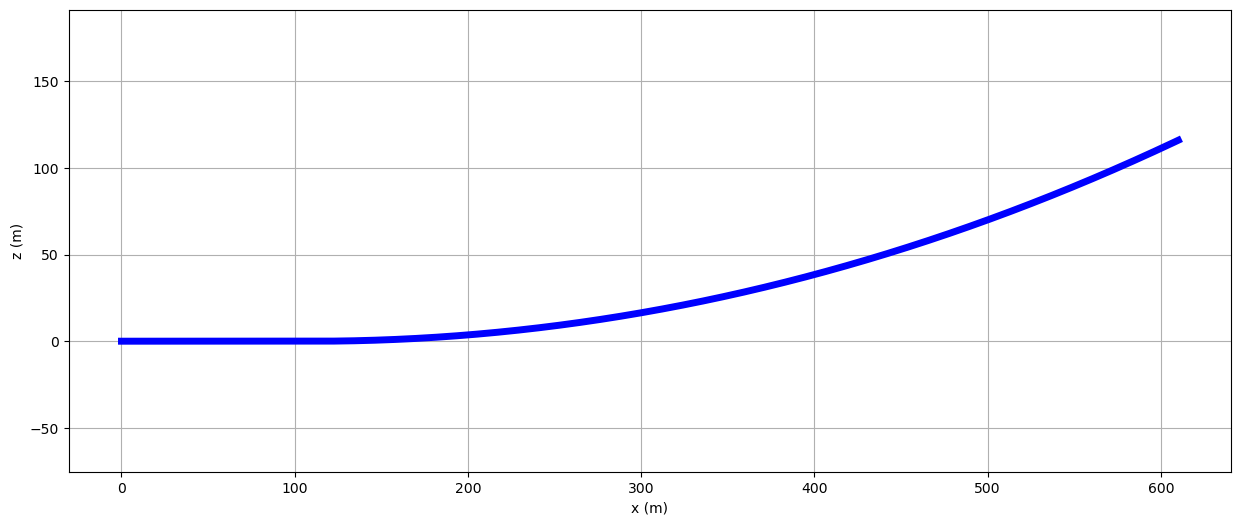

In [ ]:
V_AN = 0

x_FL1 = 600
z_FL1 = 160 - 44

max_x_FL1 = 3000
max_L_tot1 = 2000       
L_tot1 = x_FL1        


while True:

    L_tot1 = x_FL1

    while True:
        H_FL_calc1, V_FL_calc1, L_susp_calc1 = inv_catenary_end_xz(
            W_pm, L_tot1, EA, V_AN, x_FL1, z_FL1
        )

        L_on_bed = L_tot1 - L_susp_calc1

        if L_on_bed >= min_bed_length:
            break

        L_tot1 += dL

        if L_tot1 > max_L_tot1:
            raise ValueError("No suitable cable length found before reaching max_L_tot1.")

    if V_FL_calc1 >= V_target:
        break

    x_FL1 += dx_anchor

    if x_FL1 > max_x_FL1:
        raise ValueError("No suitable anchor point found before reaching max_x_FL1.")

print("Depth of this location is ", z_FL1 + 44, "m")
print("Prescribed position of the fairlead was (x_FL, z_FL) =", x_FL1, z_FL1)
print("Calculated Horizontal Force ","H_FL ",f"{H_FL_calc1/1000:.8}","kN ")
print("Calculated Vertical Force fairlead ","V_FL ",f"{V_FL_calc1/1000:.8}","kN ")
print("Calculated Suspended length ","Ls ",f"{L_susp_calc1:.8}","m ")
print("Calculated length on the bed ",f"{L_tot1 - L_susp_calc1:.8}","m ")

l2_s, l2_x, l2_z, l2_V = plot_catenary_xz(W_pm, L_tot1, EA, V_AN, H_FL_calc1, L_susp_calc1, 0.1)

plt.figure()
plt.plot(l2_x, l2_z, 'b-', lw=5)
plt.axis("equal")
plt.grid("on")
plt.xlabel('x (m)')
plt.ylabel('z (m)')
plt.show()
pass

Depth of this location is  217.5 m
Prescribed position of the fairlead was (x_FL, z_FL) = 590 173.5
Calculated Horizontal Force  H_FL  3873.2648 kN 
Calculated Vertical Force fairlead  V_FL  2919.5021 kN 
Calculated Suspended length  Ls  517.5734 m 
Calculated length on the bed  111.2266 m 
517.5733988784594 589.9999999985263 173.50000000044085 2919502.1497236704


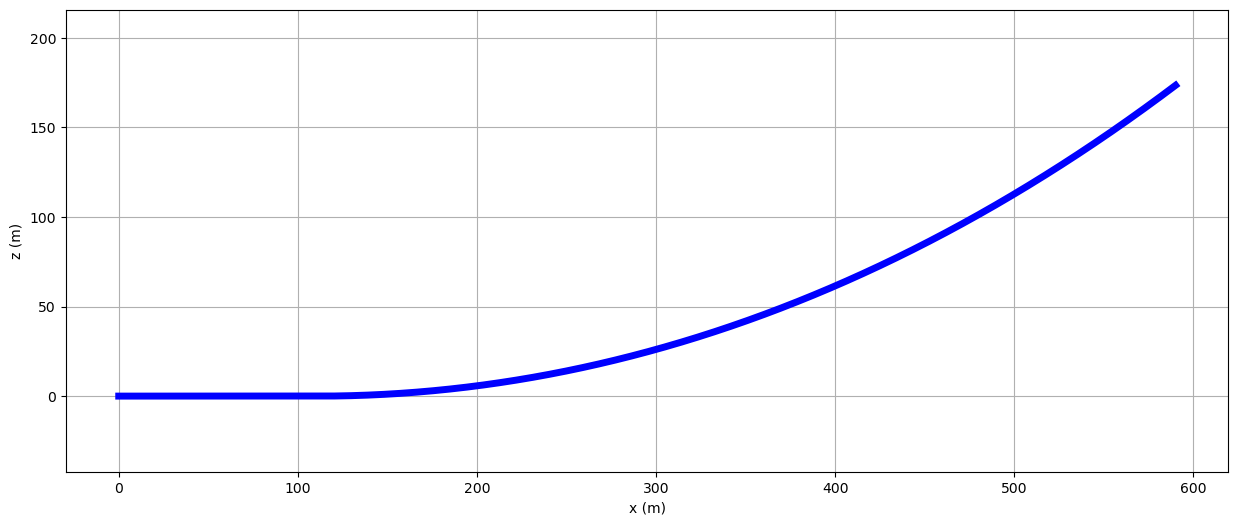

In [ ]:
V_AN = 0

x_FL2 = 580
z_FL2 = 217.5 - 44

max_x_FL2 = 2000          
max_L_tot2 = 2000     
L_tot2 = x_FL2 #m

while True:

    L_tot2 = x_FL2

    while True:
        H_FL_calc2, V_FL_calc2, L_susp_calc2 = inv_catenary_end_xz(
            W_pm, L_tot2, EA, V_AN, x_FL2, z_FL2
        )

        L_on_bed = L_tot2 - L_susp_calc2

        if L_on_bed >= min_bed_length:
            break

        L_tot2 += dL

        if L_tot2 > max_L_tot2:
            raise ValueError("No suitable cable length found before reaching max_L_tot2.")

    if V_FL_calc2 >= V_target:
        break

    x_FL2 += dx_anchor

    if x_FL2 > max_x_FL2:
        raise ValueError("No suitable anchor point found before reaching max_x_FL2.")

print("Depth of this location is ", z_FL2 + 44, "m")
print("Prescribed position of the fairlead was (x_FL, z_FL) =", x_FL2, z_FL2)
print("Calculated Horizontal Force ","H_FL ",f"{H_FL_calc2/1000:.8}","kN ")
print("Calculated Vertical Force fairlead ","V_FL ",f"{V_FL_calc2/1000:.8}","kN ")
print("Calculated Suspended length ","Ls ",f"{L_susp_calc2:.8}","m ")
print("Calculated length on the bed ",f"{L_tot2 - L_susp_calc2:.8}","m ")

l2_s, l2_x, l2_z, l2_V = plot_catenary_xz(W_pm, L_tot2, EA, V_AN, H_FL_calc2, L_susp_calc2, 0.1)

plt.figure()
plt.plot(l2_x, l2_z, 'b-', lw=5)
plt.axis("equal")
plt.grid("on")
plt.xlabel('x (m)')
plt.ylabel('z (m)')
plt.show()
pass

Depth of this location is  275 m
Prescribed position of the fairlead was (x_FL, z_FL) = 555 231
Calculated Horizontal Force  H_FL  2602.6091 kN 
Calculated Vertical Force fairlead  V_FL  2909.9549 kN 
Calculated Suspended length  Ls  515.88084 m 
Calculated length on the bed  110.41916 m 
515.8808439722847 555.0000000000218 231.00000000003584 2909954.870636665


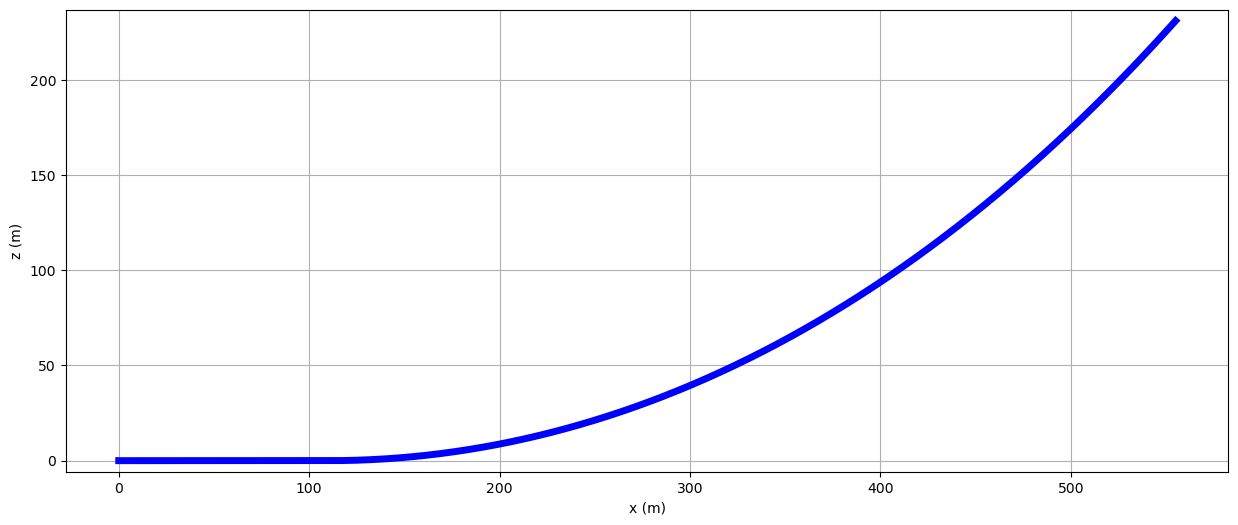

In [ ]:
V_AN = 0

x_FL3 = 550
z_FL3 = 275 - 44

max_x_FL3 = 2000          
max_L_tot3 = 2000  
L_tot3 = x_FL3 #m

while True:

    L_tot3 = x_FL3

    while True:
        H_FL_calc3, V_FL_calc3, L_susp_calc3 = inv_catenary_end_xz(
            W_pm, L_tot3, EA, V_AN, x_FL3, z_FL3
        )

        L_on_bed = L_tot3 - L_susp_calc3

        if L_on_bed >= min_bed_length:
            break

        L_tot3 += dL

        if L_tot3 > max_L_tot3:
            raise ValueError("No suitable cable length found before reaching max_L_tot3.")

    if V_FL_calc3 >= V_target:
        break

    x_FL3 += dx_anchor

    if x_FL3 > max_x_FL3:
        raise ValueError("No suitable anchor point found before reaching max_x_FL3.")

print("Depth of this location is ", z_FL3 + 44, "m")
print("Prescribed position of the fairlead was (x_FL, z_FL) =", x_FL3, z_FL3)
print("Calculated Horizontal Force ","H_FL ",f"{H_FL_calc3/1000:.8}","kN ")
print("Calculated Vertical Force fairlead ","V_FL ",f"{V_FL_calc3/1000:.8}","kN ")
print("Calculated Suspended length ","Ls ",f"{L_susp_calc3:.8}","m ")
print("Calculated length on the bed ",f"{L_tot3 - L_susp_calc3:.8}","m ")

l2_s, l2_x, l2_z, l2_V = plot_catenary_xz(W_pm, L_tot3, EA, V_AN, H_FL_calc3, L_susp_calc3, 0.1)

plt.figure()
plt.plot(l2_x, l2_z, 'b-', lw=5)
plt.axis("equal")
plt.grid("on")
plt.xlabel('x (m)')
plt.ylabel('z (m)')
plt.show()
pass

In [ ]:
#Summary of all parameters for the three lines:
print("Line 1: x_FL =", f"{x_FL1}","m, L_tot =", f"{L_tot1:.8}","m, H_FL =", f"{H_FL_calc1/1000:.8}","kN, V_FL =", f"{V_FL_calc1/1000:.8}","kN, L_susp =", f"{L_susp_calc1:.8}","m, L_bed =", f"{L_tot1 - L_susp_calc1:.8}","m")
print("Line 2: x_FL =", f"{x_FL2}","m, L_tot =", f"{L_tot2:.8}","m, H_FL =", f"{H_FL_calc2/1000:.8}","kN, V_FL =", f"{V_FL_calc2/1000:.8}","kN, L_susp =", f"{L_susp_calc2:.8}","m, L_bed =", f"{L_tot2 - L_susp_calc2:.8}","m")
print("Line 3: x_FL =", f"{x_FL3}","m, L_tot =", f"{L_tot3:.8}","m, H_FL =", f"{H_FL_calc3/1000:.8}","kN, V_FL =", f"{V_FL_calc3/1000:.8}","kN, L_susp =", f"{L_susp_calc3:.8}","m, L_bed =", f"{L_tot3 - L_susp_calc3:.8}","m")

Line 1: x_FL = 610 m, L_tot = 626.3 m, H_FL = 6150.1485 kN, V_FL = 2907.7239 kN, L_susp = 515.48534 m, L_bed = 110.81466 m
Line 2: x_FL = 590 m, L_tot = 628.8 m, H_FL = 3873.2648 kN, V_FL = 2919.5021 kN, L_susp = 517.5734 m, L_bed = 111.2266 m
Line 3: x_FL = 555 m, L_tot = 626.3 m, H_FL = 2602.6091 kN, V_FL = 2909.9549 kN, L_susp = 515.88084 m, L_bed = 110.41916 m


515.4853356771694 610.0000000000052 115.99999999996936 2907723.907220993
517.5733988784652 589.9999999985309 173.50000000044435 2919502.149723703
515.8808439722288 554.9999999999845 230.9999999999941 2909954.87063635


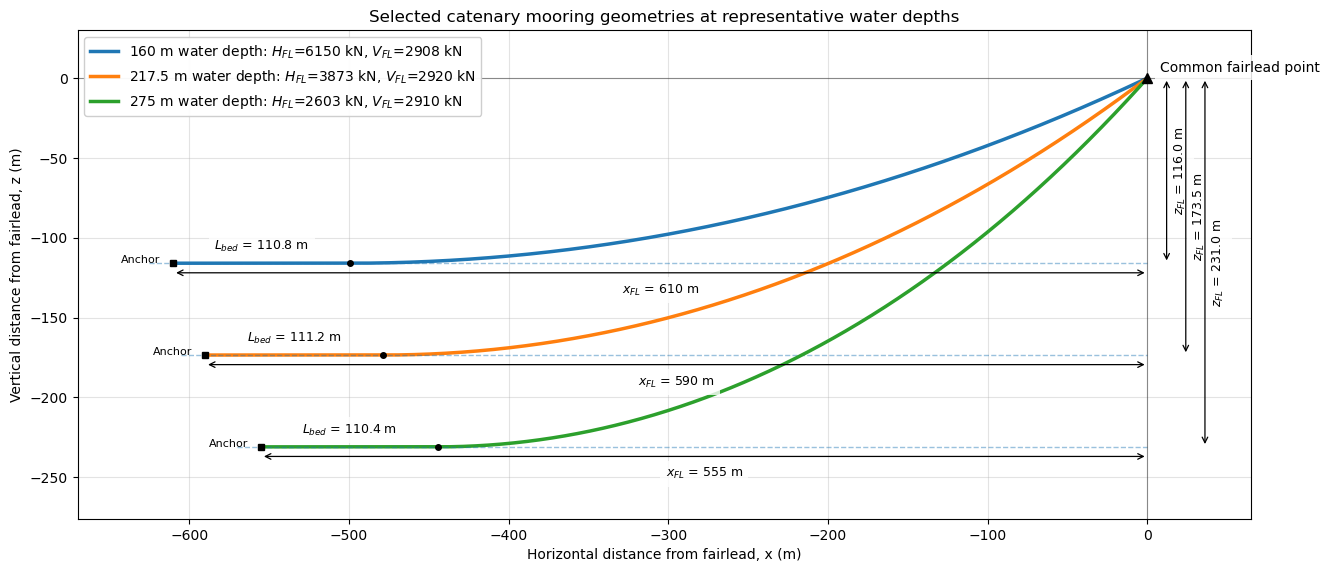

Saved figure as: Images/mooring_line_geometries.png


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

def to_kN(force):
    """Convert N to kN if needed."""
    force = float(force)
    if abs(force) > 1e4:
        return force / 1000
    return force

geometry_cases = [
    {
        "name": "160 m water depth",
        "water_depth": z_FL1 + 44,
        "x_FL": x_FL1,
        "z_FL": z_FL1,
        "L_tot": L_tot1,
        "H": H_FL_calc1,
        "L_susp": L_susp_calc1,
    },
    {
        "name": "217.5 m water depth",
        "water_depth": z_FL2 + 44,
        "x_FL": x_FL2,
        "z_FL": z_FL2,
        "L_tot": L_tot2,
        "H": H_FL_calc2,
        "L_susp": L_susp_calc2,
    },
    {
        "name": "275 m water depth",
        "water_depth": z_FL3 + 44,
        "x_FL": x_FL3,
        "z_FL": z_FL3,
        "L_tot": L_tot3,
        "H": H_FL_calc3,
        "L_susp": L_susp_calc3,
    },
]

for case in geometry_cases:
    case["L_bed"] = case["L_tot"] - case["L_susp"]
    case["H_kN"] = to_kN(case["H"])
    case["V_kN"] = W_pm * g * case["L_susp"] / 1000  # kN

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13.5, 6.5))

# Different x-positions for z_FL arrows so they don't overlap
zfl_arrow_x = {
    "160 m water depth": 12,
    "217.5 m water depth": 24,
    "275 m water depth": 36,
}

for case in geometry_cases:

    # Original catenary coordinates: anchor at (0,0), fairlead at (x_FL, z_FL)
    s, x_line, z_line, V_line = plot_catenary_xz(
        W_pm,
        case["L_tot"],
        EA,
        0,
        case["H"],
        case["L_susp"],
        0.5
    )

    x_line = np.array(x_line)
    z_line = np.array(z_line)

    # Transform to fairlead-fixed coordinates:
    # fairlead becomes (0,0), anchor becomes (-x_FL,-z_FL)
    x_plot = x_line - case["x_FL"]
    z_plot = z_line - case["z_FL"]

    anchor_x = -case["x_FL"]
    anchor_z = -case["z_FL"]
    touchdown_x = anchor_x + case["L_bed"]
    touchdown_z = anchor_z

    # Legend label with fairlead forces
    legend_label = (
        f"{case['name']}: "
        f"$H_{{FL}}$={case['H_kN']:.0f} kN, "
        f"$V_{{FL}}$={case['V_kN']:.0f} kN"
    )

    # Mooring line
    ax.plot(x_plot, z_plot, lw=2.5, label=legend_label)

    # Seabed line for this water depth
    ax.hlines(
        anchor_z,
        anchor_x - 15,
        0,
        linestyles="--",
        linewidth=1.0,
        alpha=0.45
    )

    # Anchor, touchdown and fairlead markers
    ax.plot(anchor_x, anchor_z, "s", color="black", markersize=5)
    ax.plot(touchdown_x, touchdown_z, "o", color="black", markersize=4)

    # --------------------------------------------------------
    # x_FL arrow
    # --------------------------------------------------------
    y_arrow = anchor_z - 6
    ax.annotate(
        "",
        xy=(0, y_arrow),
        xytext=(anchor_x, y_arrow),
        arrowprops=dict(arrowstyle="<->", lw=0.9)
    )

    ax.text(
        anchor_x / 2,
        y_arrow - 6,
        f"$x_{{FL}}$ = {case['x_FL']:.0f} m",
        ha="center",
        va="top",
        fontsize=9,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8)
    )

    # --------------------------------------------------------
    # z_FL arrow
    # --------------------------------------------------------
    x_arrow = zfl_arrow_x[case["name"]]
    ax.annotate(
        "",
        xy=(x_arrow, 0),
        xytext=(x_arrow, anchor_z),
        arrowprops=dict(arrowstyle="<->", lw=0.9)
    )

    ax.text(
        x_arrow + 4,
        0.5 * anchor_z,
        f"$z_{{FL}}$ = {case['z_FL']:.1f} m",
        ha="left",
        va="center",
        fontsize=9,
        rotation=90,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8)
    )

    # Bed length label centered over seabed-resting part
    ax.text(
        anchor_x + 0.5 * case["L_bed"],
        anchor_z + 6,
        f"$L_{{bed}}$ = {case['L_bed']:.1f} m",
        ha="center",
        va="bottom",
        fontsize=9,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8)
    )

    # Anchor label
    ax.text(
        anchor_x - 8,
        anchor_z + 2,
        "Anchor",
        ha="right",
        va="center",
        fontsize=8
    )

# Common fairlead point
ax.plot(0, 0, "^", color="black", markersize=7)
ax.text(
    8,
    2,
    "Common fairlead point",
    ha="left",
    va="bottom",
    fontsize=10,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.85)
)

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
max_x = max(case["x_FL"] for case in geometry_cases)
max_z = max(case["z_FL"] for case in geometry_cases)

ax.axhline(0, color="black", lw=0.8, alpha=0.4)
ax.axvline(0, color="black", lw=0.8, alpha=0.4)

ax.set_xlim(-max_x - 60, 65)
ax.set_ylim(-max_z - 45, 30)

ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.35)

ax.set_xlabel("Horizontal distance from fairlead, x (m)")
ax.set_ylabel("Vertical distance from fairlead, z (m)")
ax.set_title("Selected catenary mooring geometries at representative water depths")

# Legend in top left with H_FL and V_FL
ax.legend(loc="upper left", framealpha=0.95, fontsize=10)

plt.tight_layout()

# Save figure for report
os.makedirs("Images", exist_ok=True)
plt.savefig("Images/mooring_line_geometries.png", dpi=300, bbox_inches="tight")

plt.show()

print("Saved figure as: Images/mooring_line_geometries.png")

In [49]:
def objective_fnc(sol, *data):        
    H_AN = sol[0]
    L = sol[1] #suspended length
    W_pm, L_tot, EA, V_AN, xtarg, ztarg  = data
    x, z = catenary_end_xz(W_pm, L_tot, EA, V_AN, H_AN, L)    
    return np.array( [abs(ztarg-z),  abs(xtarg-x)] )

C:\Users\jholl\AppData\Local\Temp\ipykernel_35144\2835706092.py:86: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol1 = optimize.fsolve(
C:\Users\jholl\AppData\Local\Temp\ipykernel_35144\2835706092.py:92: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol2 = optimize.fsolve(


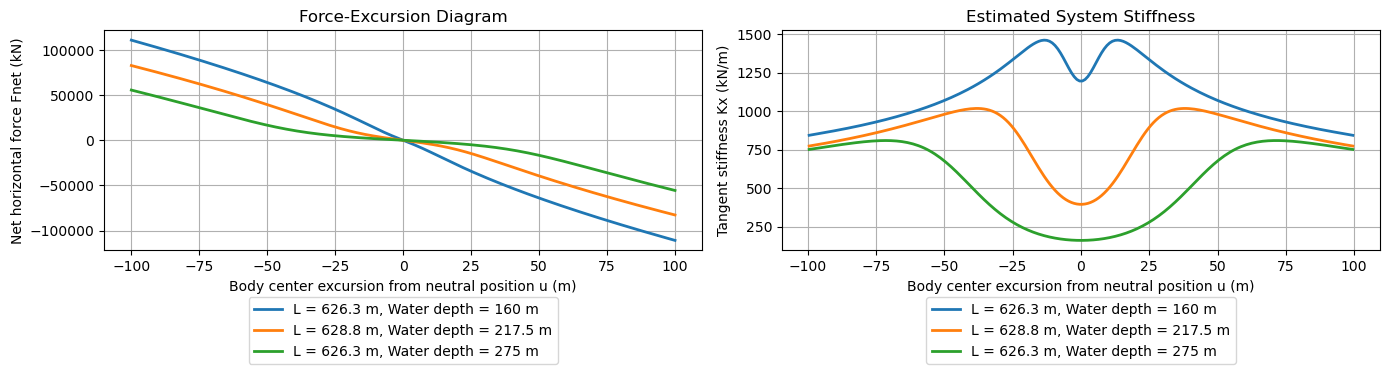

L = 626.3 m, Water depth = 160 m
Range of Fnet (kN): -110886.5566741975 to 110886.55455471377
Range of Kx (kN/m): 843.3556471480429 to 1460.5654381949305

L = 628.8 m, Water depth = 217.5 m
Range of Fnet (kN): -82756.52021609856 to 82756.52021416365
Range of Kx (kN/m): 395.7837106095916 to 1017.4609782750272

L = 626.3 m, Water depth = 275 m
Range of Fnet (kN): -55604.54474175996 to 55604.54474443313
Range of Kx (kN/m): 161.7729321793234 to 809.3739462096356

Stiffness range summary:
L = 626.3 m, Water depth = 160 m: 843.36 to 1460.57 kN/m
L = 628.8 m, Water depth = 217.5 m: 395.78 to 1017.46 kN/m
L = 626.3 m, Water depth = 275 m: 161.77 to 809.37 kN/m


In [ ]:
# Horizontal excursion

g = 9.81  # m/s2

# Fairlead spacing on body
moor_sep = 27.7  # m

# Excursion sweep around neutral position
u_min = -100
u_max = 100
u_step = 1
u_array = np.arange(u_min, u_max + u_step, u_step)

#actual water depths at the three locations:
z1 = z_FL1 + 44
z2 = z_FL2 + 44
z3 = z_FL3 + 44

# Define all geometry cases
# Ordered from shallowest to deepest water depth
cases = [
    {
        "label": f"L = {L_tot1:.1f} m, Water depth = {z1:g} m",
        "W_pm": W_pm,
        "EA": EA,
        "L_tot": L_tot1,
        "x_FL_neutral": x_FL1,
        "d0": z_FL1,
    },
    {
        "label": f"L = {L_tot2:.1f} m, Water depth = {z2:g} m",
        "W_pm": W_pm,
        "EA": EA,
        "L_tot": L_tot2,
        "x_FL_neutral": x_FL2,
        "d0": z_FL2,
    },
    {
        "label": f"L = {L_tot3:.1f} m, Water depth = {z3:g} m",
        "W_pm": W_pm,
        "EA": EA,
        "L_tot": L_tot3,
        "x_FL_neutral": x_FL3,
        "d0": z_FL3,
    },
]

# Storage for results
results = []

for case in cases:

    W_pm = case["W_pm"]
    EA = case["EA"]
    L_tot = case["L_tot"]
    d0 = case["d0"]
    x_FL_neutral = case["x_FL_neutral"]

    # Anchor-to-anchor spacing follows from neutral fairlead distance
    anch_sep = 2 * x_FL_neutral + moor_sep

    # Neutral body center position
    x0_neutral = anch_sep / 2

    # Body center positions
    x0_targ_array = x0_neutral + u_array

    # Build fairlead target arrays from body center position
    x1_targ_array = [x0 - moor_sep / 2 for x0 in x0_targ_array]
    x2_targ_array = [anch_sep - moor_sep - x1 for x1 in x1_targ_array]

    z1_targ = d0
    z2_targ = d0

    H1_array = []
    H2_array = []
    L1_susp_array = []
    L2_susp_array = []

    guess1 = np.array([10.0, 10.0])
    guess2 = np.array([10.0, 10.0])

    for x1_targ, x2_targ in zip(x1_targ_array, x2_targ_array):

        sol1 = optimize.fsolve(
            objective_fnc,
            guess1,
            args=(W_pm, L_tot, EA, 0, x1_targ, z1_targ)
        )

        sol2 = optimize.fsolve(
            objective_fnc,
            guess2,
            args=(W_pm, L_tot, EA, 0, x2_targ, z2_targ)
        )

        H1, L1_susp = sol1
        H2, L2_susp = sol2

        H1_array.append(H1)
        H2_array.append(H2)
        L1_susp_array.append(L1_susp)
        L2_susp_array.append(L2_susp)

        guess1 = sol1
        guess2 = sol2

    # Net horizontal restoring force
    Fnet_array = np.array(H2_array) - np.array(H1_array)

    # Tangent stiffness
    dx = x0_targ_array[1] - x0_targ_array[0]
    Kx = -np.diff(Fnet_array) / dx
    u_mid = u_array[:-1] + dx / 2

    results.append({
        "label": case["label"],
        "u_array": u_array,
        "u_mid": u_mid,
        "Fnet_array": Fnet_array,
        "Kx": Kx,
    })


# --- Plots ---
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# Force-excursion plot
for res in results:
    ax[0].plot(
        res["u_array"],
        res["Fnet_array"] / 1000,
        lw=2,
        label=res["label"]
    )

ax[0].grid(True)
ax[0].set_xlabel("Body center excursion from neutral position u (m)")
ax[0].set_ylabel("Net horizontal force Fnet (kN)")
ax[0].set_title("Force-Excursion Diagram")
ax[0].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=1
)

# Stiffness plot
for res in results:
    ax[1].plot(
        res["u_mid"],
        res["Kx"] / 1000,
        lw=2,
        label=res["label"]
    )

ax[1].grid(True)
ax[1].set_xlabel("Body center excursion from neutral position u (m)")
ax[1].set_ylabel("Tangent stiffness Kx (kN/m)")
ax[1].set_title("Estimated System Stiffness")
ax[1].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=1
)

plt.tight_layout()
plt.show()


# Print ranges
for res in results:
    print(res["label"])
    print("Range of Fnet (kN):", np.min(res["Fnet_array"]) / 1000, "to", np.max(res["Fnet_array"]) / 1000)
    print("Range of Kx (kN/m):", np.min(res["Kx"]) / 1000, "to", np.max(res["Kx"]) / 1000)
    print()

print("Stiffness range summary:")
for res in results:
    print(f"{res['label']}: {np.min(res['Kx']) / 1000:.2f} to {np.max(res['Kx']) / 1000:.2f} kN/m")

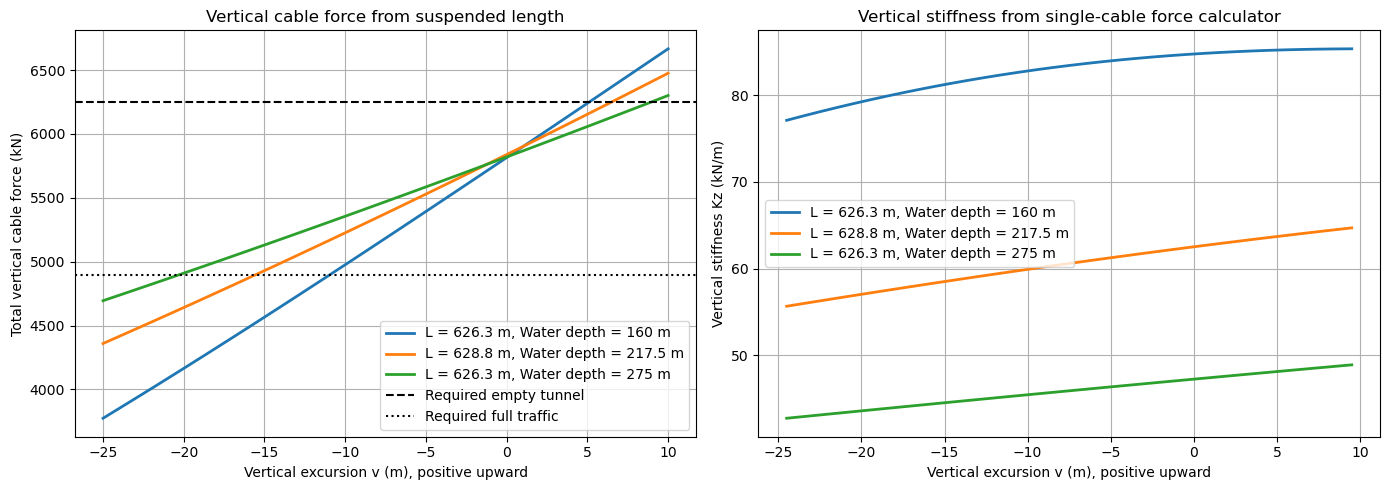

L = 626.3 m, Water depth = 160 m
Suspended length at neutral, single cable: 515.49 m
Total vertical force at neutral: 5815.45 kN
Vertical stiffness around neutral: 84.79 kN/m
Minimum chain length on seabed: 35.35 m

L = 628.8 m, Water depth = 217.5 m
Suspended length at neutral, single cable: 517.57 m
Total vertical force at neutral: 5839.00 kN
Vertical stiffness around neutral: 62.64 kN/m
Minimum chain length on seabed: 54.77 m

L = 626.3 m, Water depth = 275 m
Suspended length at neutral, single cable: 515.88 m
Total vertical force at neutral: 5819.91 kN
Vertical stiffness around neutral: 47.36 kN/m
Minimum chain length on seabed: 67.75 m



In [ ]:
# Vertical excursion

def objective_fnc_signed(sol, *data):
    H_AN = sol[0]
    L_susp = sol[1]

    W_pm, L_tot, EA, V_AN, x_target, z_target = data

    x_calc, z_calc = catenary_end_xz(
        W_pm, L_tot, EA, V_AN, H_AN, L_susp
    )

    return np.array([
        z_target - z_calc,
        x_target - x_calc
    ])


def solve_single_cable_force(W_pm, L_tot, EA, x_target, z_target, guess):
    sol = optimize.fsolve(
        objective_fnc_signed,
        guess,
        args=(W_pm, L_tot, EA, 0, x_target, z_target)
    )

    H, L_susp = sol

    V = W_pm * g * L_susp
    L_bed = L_tot - L_susp

    return H, L_susp, V, L_bed, sol


# Excursion sweep around neutral position
v_min = -25      # downward
v_max = 10       # upward
v_step = 1
v_array = np.arange(v_min, v_max + v_step, v_step)

vertical_results_clean = []

for case in cases:

    W_pm_case = case["W_pm"]
    EA_case = case["EA"]
    L_tot = case["L_tot"]
    d0 = case["d0"]
    x_FL_neutral = case["x_FL_neutral"]

    x_target = x_FL_neutral

    z_array = d0 + v_array

    H_array = []
    L_susp_array = []
    V_single_array = []
    L_bed_array = []

    H0, L0, V0, L_bed0, guess = solve_single_cable_force(
        W_pm_case,
        L_tot,
        EA_case,
        x_target,
        d0,
        np.array([1e6, 500.0])
    )

    for z_target in z_array:

        H, L_susp, V_single, L_bed, guess = solve_single_cable_force(
            W_pm_case,
            L_tot,
            EA_case,
            x_target,
            z_target,
            guess
        )

        H_array.append(H)
        L_susp_array.append(L_susp)
        V_single_array.append(V_single)
        L_bed_array.append(L_bed)

    H_array = np.array(H_array)
    L_susp_array = np.array(L_susp_array)
    V_single_array = np.array(V_single_array)
    L_bed_array = np.array(L_bed_array)

    Fz_total_array = 2 * V_single_array

    dv = v_array[1] - v_array[0]
    Kz_total = np.diff(Fz_total_array) / dv
    v_mid = v_array[:-1] + dv / 2

    vertical_results_clean.append({
        "label": case["label"],
        "v_array": v_array,
        "v_mid": v_mid,
        "L_susp_array": L_susp_array,
        "L_bed_array": L_bed_array,
        "Fz_total_array": Fz_total_array,
        "Kz_total": Kz_total,
    })


fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for res in vertical_results_clean:
    ax[0].plot(
        res["v_array"],
        res["Fz_total_array"] / 1000,
        lw=2,
        label=res["label"]
    )

ax[0].axhline(F_required_empty_kN, linestyle="--", color="black", label="Required empty tunnel")
ax[0].axhline(F_required_full_kN, linestyle=":", color="black", label="Required full traffic")

ax[0].grid(True)
ax[0].set_xlabel("Vertical excursion v (m), positive upward")
ax[0].set_ylabel("Total vertical cable force (kN)")
ax[0].set_title("Vertical cable force from suspended length")
ax[0].legend()


for res in vertical_results_clean:
    ax[1].plot(
        res["v_mid"],
        res["Kz_total"] / 1000,
        lw=2,
        label=res["label"]
    )

ax[1].grid(True)
ax[1].set_xlabel("Vertical excursion v (m), positive upward")
ax[1].set_ylabel("Vertical stiffness Kz (kN/m)")
ax[1].set_title("Vertical stiffness from single-cable force calculator")
ax[1].legend()

plt.tight_layout()
plt.show()


for res in vertical_results_clean:
    neutral_index = np.argmin(np.abs(res["v_array"]))

    print(res["label"])
    print("Suspended length at neutral, single cable:",
          f"{res['L_susp_array'][neutral_index]:.2f}", "m")

    print("Total vertical force at neutral:",
          f"{res['Fz_total_array'][neutral_index] / 1000:.2f}", "kN")

    print("Vertical stiffness around neutral:",
          f"{res['Kz_total'][neutral_index] / 1000:.2f}", "kN/m")

    print("Minimum chain length on seabed:",
          f"{np.min(res['L_bed_array']):.2f}", "m")

    print()

Original graph depths: [160.  217.5 275. ]


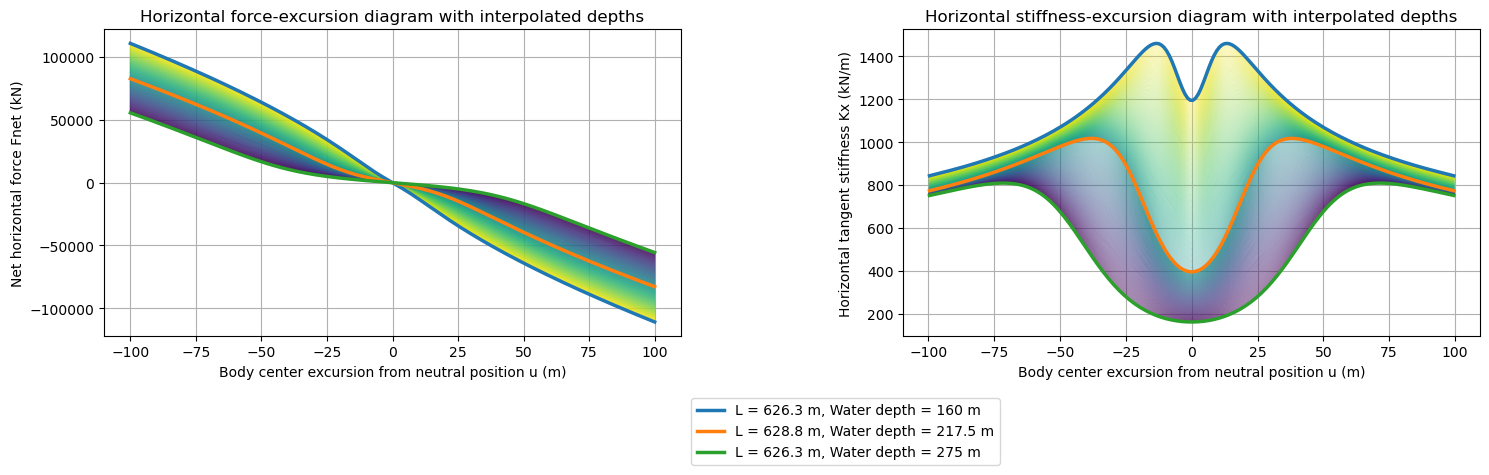

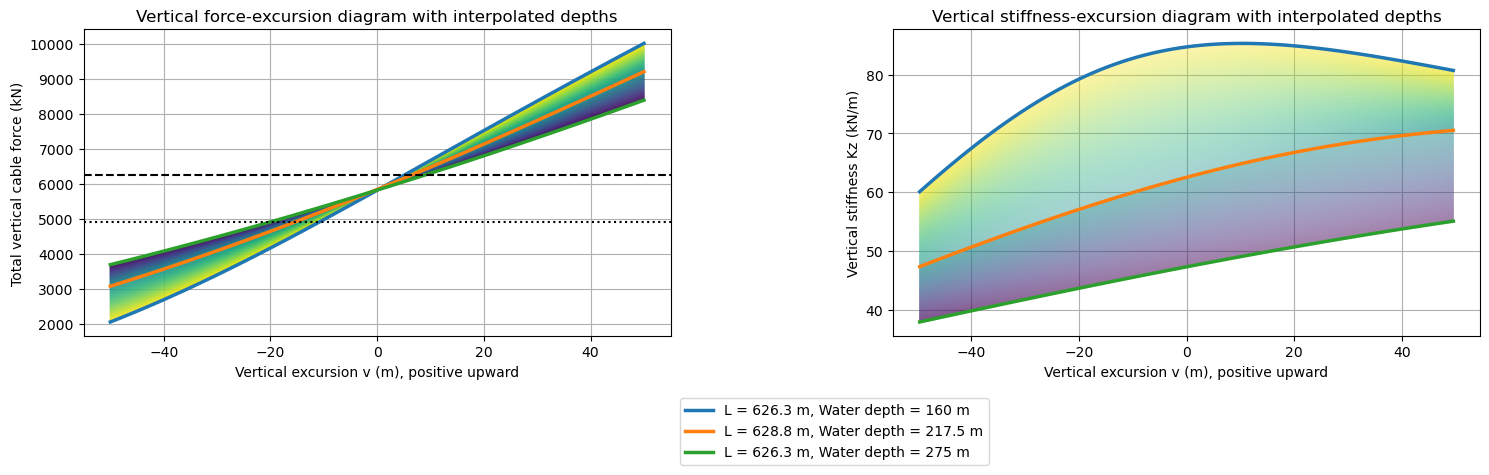

In [52]:
# ============================================================
# Plot stiffness/force vs excursion for ALL interpolated depths
# every 25 m along the tunnel
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Interpolated depth profile along the tunnel
# ------------------------------------------------------------

x_profile = np.arange(0, 10000 + 25, 25)   # every 25 m

x_known = np.array([0, 5000, 10000])
depth_known = np.array([275, 217.5, 160])

depth_profile = np.interp(x_profile, x_known, depth_known)

# ------------------------------------------------------------
# 2. Get the three original depths used in the catenary graphs
# ------------------------------------------------------------

base_depths = np.array([case["d0"] + 44 for case in cases])

sort_idx = np.argsort(base_depths)
base_depths_sorted = base_depths[sort_idx]

print("Original graph depths:", base_depths_sorted)

# ------------------------------------------------------------
# 3. Collect original horizontal curves
# ------------------------------------------------------------

u_array = results[0]["u_array"]
u_mid = results[0]["u_mid"]

Fnet_base = np.array([res["Fnet_array"] for res in results])[sort_idx, :]
Kx_base = np.array([res["Kx"] for res in results])[sort_idx, :]

# ------------------------------------------------------------
# 4. Collect original vertical curves
# ------------------------------------------------------------

v_array = vertical_results_clean[0]["v_array"]
v_mid = vertical_results_clean[0]["v_mid"]

Fz_base = np.array([res["Fz_total_array"] for res in vertical_results_clean])[sort_idx, :]
Kz_base = np.array([res["Kz_total"] for res in vertical_results_clean])[sort_idx, :]

# ------------------------------------------------------------
# 5. Function to interpolate complete curves between depths
# ------------------------------------------------------------

def interpolate_curve_family(depth_profile, base_depths_sorted, base_curves_sorted):
    """
    Interpolates a full curve for every depth in depth_profile.

    base_curves_sorted has shape:
    number of original depths x number of excursion points

    output has shape:
    number of interpolated depths x number of excursion points
    """

    interpolated_curves = []

    for j in range(base_curves_sorted.shape[1]):
        values_at_this_excursion = base_curves_sorted[:, j]

        interpolated_values = np.interp(
            depth_profile,
            base_depths_sorted,
            values_at_this_excursion
        )

        interpolated_curves.append(interpolated_values)

    return np.array(interpolated_curves).T

# ------------------------------------------------------------
# 6. Interpolate all force and stiffness curves
# ------------------------------------------------------------

Fnet_all = interpolate_curve_family(depth_profile, base_depths_sorted, Fnet_base)
Kx_all = interpolate_curve_family(depth_profile, base_depths_sorted, Kx_base)

Fz_all = interpolate_curve_family(depth_profile, base_depths_sorted, Fz_base)
Kz_all = interpolate_curve_family(depth_profile, base_depths_sorted, Kz_base)

# ------------------------------------------------------------
# 7. Horizontal plots: same view as before, but all depths included
# ------------------------------------------------------------

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

colors = plt.cm.viridis(np.linspace(0, 1, len(depth_profile)))

for i, depth in enumerate(depth_profile):
    ax[0].plot(
        u_array,
        Fnet_all[i, :] / 1000,
        lw=0.8,
        alpha=0.25,
        color=colors[i]
    )

    ax[1].plot(
        u_mid,
        Kx_all[i, :] / 1000,
        lw=0.8,
        alpha=0.25,
        color=colors[i]
    )

# Plot original 3 depth curves thicker on top
for res in results:
    ax[0].plot(
        res["u_array"],
        res["Fnet_array"] / 1000,
        lw=2.5,
        label=res["label"]
    )

    ax[1].plot(
        res["u_mid"],
        res["Kx"] / 1000,
        lw=2.5,
        label=res["label"]
    )

ax[0].grid(True)
ax[0].set_xlabel("Body center excursion from neutral position u (m)")
ax[0].set_ylabel("Net horizontal force Fnet (kN)")
ax[0].set_title("Horizontal force-excursion diagram with interpolated depths")

ax[1].grid(True)
ax[1].set_xlabel("Body center excursion from neutral position u (m)")
ax[1].set_ylabel("Horizontal tangent stiffness Kx (kN/m)")
ax[1].set_title("Horizontal stiffness-excursion diagram with interpolated depths")

ax[1].legend(
    loc="upper center",
    bbox_to_anchor=(-0.1, -0.18),
    ncol=1
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Vertical plots: same view as before, but all depths included
# ------------------------------------------------------------

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

colors = plt.cm.viridis(np.linspace(0, 1, len(depth_profile)))

for i, depth in enumerate(depth_profile):
    ax[0].plot(
        v_array,
        Fz_all[i, :] / 1000,
        lw=0.8,
        alpha=0.25,
        color=colors[i]
    )

    ax[1].plot(
        v_mid,
        Kz_all[i, :] / 1000,
        lw=0.8,
        alpha=0.25,
        color=colors[i]
    )

# Plot original 3 depth curves thicker on top
for res in vertical_results_clean:
    ax[0].plot(
        res["v_array"],
        res["Fz_total_array"] / 1000,
        lw=2.5,
        label=res["label"]
    )

    ax[1].plot(
        res["v_mid"],
        res["Kz_total"] / 1000,
        lw=2.5,
        label=res["label"]
    )

ax[0].axhline(F_required_empty_kN, linestyle="--", color="black", label="Required empty tunnel")
ax[0].axhline(F_required_full_kN, linestyle=":", color="black", label="Required full traffic")

ax[0].grid(True)
ax[0].set_xlabel("Vertical excursion v (m), positive upward")
ax[0].set_ylabel("Total vertical cable force (kN)")
ax[0].set_title("Vertical force-excursion diagram with interpolated depths")

ax[1].grid(True)
ax[1].set_xlabel("Vertical excursion v (m), positive upward")
ax[1].set_ylabel("Vertical stiffness Kz (kN/m)")
ax[1].set_title("Vertical stiffness-excursion diagram with interpolated depths")

ax[1].legend(
    loc="upper center",
    bbox_to_anchor=(-0.1, -0.18),
    ncol=1
)

plt.tight_layout()
plt.show()

In [53]:
# ============================================================
# Save interpolated stiffness curves for FEM model
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Depth profile every 25 m along the 10 km catenary zone
# ------------------------------------------------------------

x_profile = np.arange(0, 10000 + 25, 25)

x_known = np.array([0, 5000, 10000])
depth_known = np.array([275, 217.5, 160])

depth_profile = np.interp(x_profile, x_known, depth_known)

# ------------------------------------------------------------
# Original calculated graph depths
# ------------------------------------------------------------

base_depths = np.array([case["d0"] + 44 for case in cases])

sort_idx = np.argsort(base_depths)
base_depths_sorted = base_depths[sort_idx]

# ------------------------------------------------------------
# Original horizontal stiffness curves
# ------------------------------------------------------------

u_mid = results[0]["u_mid"]

Kx_base = np.array([
    res["Kx"] for res in results
])[sort_idx, :]

# ------------------------------------------------------------
# Original vertical stiffness curves
# ------------------------------------------------------------

v_mid = vertical_results_clean[0]["v_mid"]

Kz_base = np.array([
    res["Kz_total"] for res in vertical_results_clean
])[sort_idx, :]

# ------------------------------------------------------------
# Interpolate full stiffness curves over depth
# ------------------------------------------------------------

def interpolate_curve_family(depth_profile, base_depths_sorted, base_curves_sorted):
    interpolated_curves = []

    for j in range(base_curves_sorted.shape[1]):
        values_at_this_excursion = base_curves_sorted[:, j]

        interpolated_values = np.interp(
            depth_profile,
            base_depths_sorted,
            values_at_this_excursion
        )

        interpolated_curves.append(interpolated_values)

    return np.array(interpolated_curves).T

Kx_all = interpolate_curve_family(
    depth_profile,
    base_depths_sorted,
    Kx_base
)

Kz_all = interpolate_curve_family(
    depth_profile,
    base_depths_sorted,
    Kz_base
)

# ------------------------------------------------------------
# Save full curve data for FEM
# ------------------------------------------------------------

np.savez(
    "mooring_stiffness_curves_every_25m.npz",
    x_profile=x_profile,
    depth_profile=depth_profile,
    u_mid=u_mid,
    v_mid=v_mid,
    Kx_all=Kx_all,
    Kz_all=Kz_all
)

print("Saved: mooring_stiffness_curves_every_25m.npz")

# Also save neutral stiffness as CSV for checking
k_h_neutral = np.array([
    np.interp(0.0, u_mid, Kx_all[i, :])
    for i in range(len(x_profile))
])

k_v_neutral = np.array([
    np.interp(0.0, v_mid, Kz_all[i, :])
    for i in range(len(x_profile))
])

df_neutral = pd.DataFrame({
    "x_m": x_profile,
    "depth_m": depth_profile,
    "k_h_N_per_m": k_h_neutral,
    "k_v_N_per_m": k_v_neutral,
    "k_h_kN_per_m": k_h_neutral / 1000,
    "k_v_kN_per_m": k_v_neutral / 1000
})

df_neutral.to_csv(
    "mooring_neutral_stiffness_every_25m.csv",
    index=False
)

print("Saved: mooring_neutral_stiffness_every_25m.csv")

Saved: mooring_stiffness_curves_every_25m.npz
Saved: mooring_neutral_stiffness_every_25m.csv


C:\Users\jholl\AppData\Local\Temp\ipykernel_35144\2114127919.py:83: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  sol1 = optimize.fsolve(
C:\Users\jholl\AppData\Local\Temp\ipykernel_35144\2114127919.py:83: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol1 = optimize.fsolve(
C:\Users\jholl\AppData\Local\Temp\ipykernel_35144\2114127919.py:89: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol2 = optimize.fsolve(


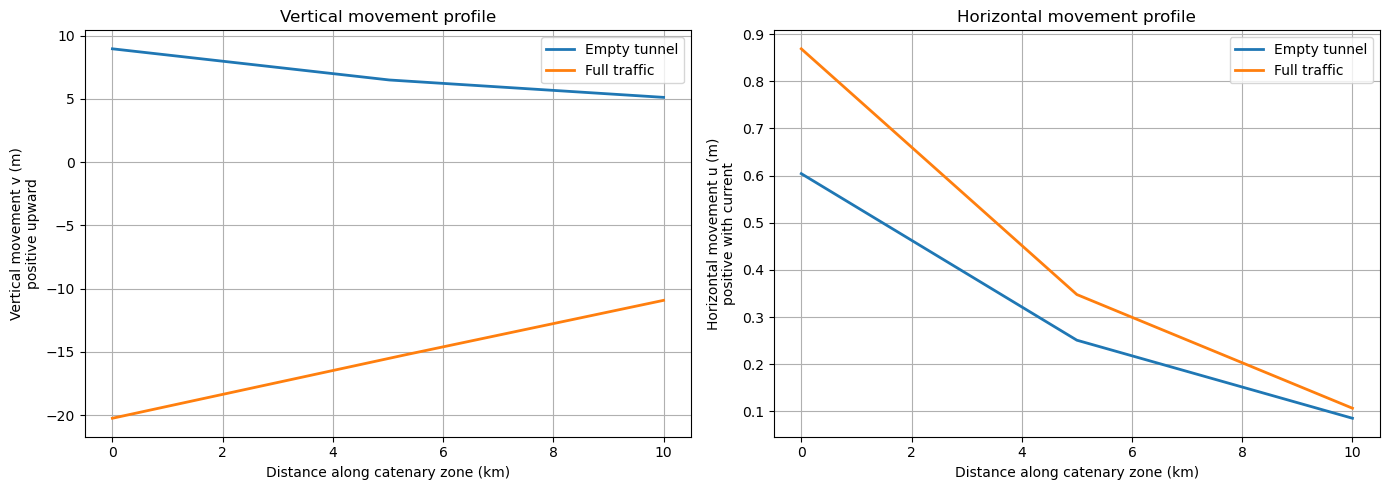

Saved figure as: Images/movement_profiles_empty_full.png
Movement profile summary
------------------------------------------------------------
Empty tunnel
  Vertical movement range:   5.11 to 8.95 m
  Horizontal movement range: 0.086 to 0.604 m

Full traffic
  Vertical movement range:   -20.25 to -10.93 m
  Horizontal movement range: 0.107 to 0.869 m



In [54]:
# ============================================================
# Movement profiles for empty and full tunnel conditions
# Only plots vertical and horizontal movement profiles
# Paste after the cells that define: cases, results, vertical_results_clean
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
import os

# -----------------------------
# User inputs / assumptions
# -----------------------------
x_profile = np.arange(0, 10000 + 25, 25)  # catenary zone, every 25 m

# Depth profile used for interpolation: deep -> midpoint -> shallow
x_known = np.array([0, 5000, 10000])
depth_known = np.array([275, 217.5, 160])
depth_profile = np.interp(x_profile, x_known, depth_known)

# Current load from conceptual horizontal check
q_current_tot_kN_per_m = 4.34  # kN/m
F_current_segment_N = q_current_tot_kN_per_m * segment_length * 1000  # N per segment

load_states = {
    "Empty tunnel": F_required_empty_kN,
    "Full traffic": F_required_full_kN
}

# -----------------------------
# Helper functions
# -----------------------------
def interpolate_over_depth(depth_profile, base_depths, base_values):
    order = np.argsort(base_depths)
    return np.interp(depth_profile, base_depths[order], base_values[order])

def checked_interp(x_target, x_curve, y_curve, label=""):
    order = np.argsort(x_curve)
    x_sorted = np.asarray(x_curve)[order]
    y_sorted = np.asarray(y_curve)[order]

    if x_target < x_sorted[0] or x_target > x_sorted[-1]:
        print(
            f"Warning: target {label} = {x_target:.2f} is outside interpolation range "
            f"[{x_sorted[0]:.2f}, {x_sorted[-1]:.2f}]. Result is clipped."
        )

    return np.interp(x_target, x_sorted, y_sorted)

def solve_horizontal_curve_at_vertical_shift(case, v_shift, u_sweep):
    W_pm_case = case["W_pm"]
    EA_case = case["EA"]
    L_tot = case["L_tot"]
    d0 = case["d0"]
    x_FL_neutral = case["x_FL_neutral"]

    anch_sep = 2 * x_FL_neutral + moor_sep
    x0_neutral = anch_sep / 2

    z_target = d0 + v_shift

    H0, L0, V0, L_bed0, guess0 = solve_single_cable_force(
        W_pm_case,
        L_tot,
        EA_case,
        x_FL_neutral,
        z_target,
        np.array([1e6, 500.0])
    )

    guess1 = guess0.copy()
    guess2 = guess0.copy()

    Fnet = []

    for u in u_sweep:
        x0 = x0_neutral + u

        x1_target = x0 - moor_sep / 2
        x2_target = anch_sep - x0 - moor_sep / 2

        sol1 = optimize.fsolve(
            objective_fnc_signed,
            guess1,
            args=(W_pm_case, L_tot, EA_case, 0, x1_target, z_target)
        )

        sol2 = optimize.fsolve(
            objective_fnc_signed,
            guess2,
            args=(W_pm_case, L_tot, EA_case, 0, x2_target, z_target)
        )

        H1, L1_susp = sol1
        H2, L2_susp = sol2

        Fnet.append(H2 - H1)

        guess1 = sol1
        guess2 = sol2

    return np.array(Fnet)

def solve_horizontal_displacement_from_current(u_sweep, Fnet_curve, F_current_N):
    target_Fnet = -F_current_N
    u_sol = checked_interp(target_Fnet, Fnet_curve, u_sweep, label="horizontal restoring force")

    if u_sol < 0:
        u_alt = checked_interp(F_current_N, Fnet_curve, u_sweep, label="horizontal restoring force")
        if u_alt > u_sol:
            u_sol = u_alt

    return u_sol

# -----------------------------
# 1. Vertical movement profiles
# -----------------------------
base_depths = np.array([case["d0"] + 44 for case in cases])

vertical_base = {state: [] for state in load_states}

for state, F_required_kN in load_states.items():
    for res in vertical_results_clean:
        F_curve_kN = res["Fz_total_array"] / 1000
        v_curve = res["v_array"]

        v_req = checked_interp(
            F_required_kN,
            F_curve_kN,
            v_curve,
            label=f"{state} vertical force"
        )

        vertical_base[state].append(v_req)

vertical_base = {
    state: np.array(values)
    for state, values in vertical_base.items()
}

vertical_profile = {
    state: interpolate_over_depth(depth_profile, base_depths, values)
    for state, values in vertical_base.items()
}

# -----------------------------
# 2. Horizontal movement profiles under current
# -----------------------------
u_sweep = np.arange(-100, 100 + 1, 1)

horizontal_base = {state: [] for state in load_states}

for state in load_states:
    for case, v_shift in zip(cases, vertical_base[state]):
        Fnet_curve = solve_horizontal_curve_at_vertical_shift(
            case,
            v_shift,
            u_sweep
        )

        u_req = solve_horizontal_displacement_from_current(
            u_sweep,
            Fnet_curve,
            F_current_segment_N
        )

        horizontal_base[state].append(u_req)

horizontal_base = {
    state: np.array(values)
    for state, values in horizontal_base.items()
}

horizontal_profile = {
    state: interpolate_over_depth(depth_profile, base_depths, values)
    for state, values in horizontal_base.items()
}

# -----------------------------
# 3. Plot only the movement profiles
# -----------------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for state in load_states:
    ax[0].plot(
        x_profile / 1000,
        vertical_profile[state],
        lw=2,
        label=state
    )

    ax[1].plot(
        x_profile / 1000,
        horizontal_profile[state],
        lw=2,
        label=state
    )

ax[0].set_title("Vertical movement profile")
ax[0].set_xlabel("Distance along catenary zone (km)")
ax[0].set_ylabel("Vertical movement v (m)\npositive upward")
ax[0].grid(True)
ax[0].legend()

ax[1].set_title("Horizontal movement profile")
ax[1].set_xlabel("Distance along catenary zone (km)")
ax[1].set_ylabel("Horizontal movement u (m)\npositive with current")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()

# Save figure for report
os.makedirs("Images", exist_ok=True)
plt.savefig("Images/movement_profiles_empty_full.png", dpi=300, bbox_inches="tight")

plt.show()

print("Saved figure as: Images/movement_profiles_empty_full.png")

# -----------------------------
# 4. Short movement summary
# -----------------------------
print("Movement profile summary")
print("-" * 60)

for state in load_states:
    print(state)
    print(f"  Vertical movement range:   {np.min(vertical_profile[state]):.2f} to {np.max(vertical_profile[state]):.2f} m")
    print(f"  Horizontal movement range: {np.min(horizontal_profile[state]):.3f} to {np.max(horizontal_profile[state]):.3f} m")
    print()